In [ ]:
# ─────────────────────────────────────────────────────────────────────
# Brain Tumor MRI Classification — EfficientNetB3
# Dataset: Brain Tumor MRI Dataset by Masoud Nickparvar (Kaggle)
# Model: EfficientNetB3 with transfer learning
# Classes: Glioma | Meningioma | No Tumor | Pituitary
# ─────────────────────────────────────────────────────────────────────

import os
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
from sklearn.metrics import classification_report, confusion_matrix

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
print(f"PyTorch version: {torch.__version__}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

GPU: NVIDIA GeForce RTX 5060 Laptop GPU
Using device: cuda
PyTorch version: 2.10.0+cu128


In [ ]:
# ─────────────────────────────────────────────────────────────────────
# Data Loading & Preprocessing
# ─────────────────────────────────────────────────────────────────────

def remove_bad_images(folder_path):
    removed = 0
    for class_name in os.listdir(folder_path):
        class_path = os.path.join(folder_path, class_name)
        for img_name in os.listdir(class_path):
            img_path = os.path.join(class_path, img_name)
            try:
                img = Image.open(img_path)
                img.verify()
                img.close()
            except (IOError, SyntaxError, Image.UnidentifiedImageError):
                try:
                    os.remove(img_path)
                    removed += 1
                except PermissionError:
                    print(f"Skipped locked file: {img_name}")
    print(f"Removed {removed} corrupted image(s) from {folder_path}")

remove_bad_images("Training")
remove_bad_images("Testing")

# EfficientNetB3 expects 300x300
IMG_SIZE = 300

train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

test_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

train_dataset = datasets.ImageFolder("Training", transform=train_transforms)
test_dataset  = datasets.ImageFolder("Testing",  transform=test_transforms)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True,  num_workers=0, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=32, shuffle=False, num_workers=0, pin_memory=True)

class_names = train_dataset.classes

print(f"Classes: {class_names}")
print(f"Training images: {len(train_dataset)}")
print(f"Testing images:  {len(test_dataset)}")

Removed 0 corrupted image(s) from Training
Removed 0 corrupted image(s) from Testing
Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']
Training images: 5599
Testing images:  1600


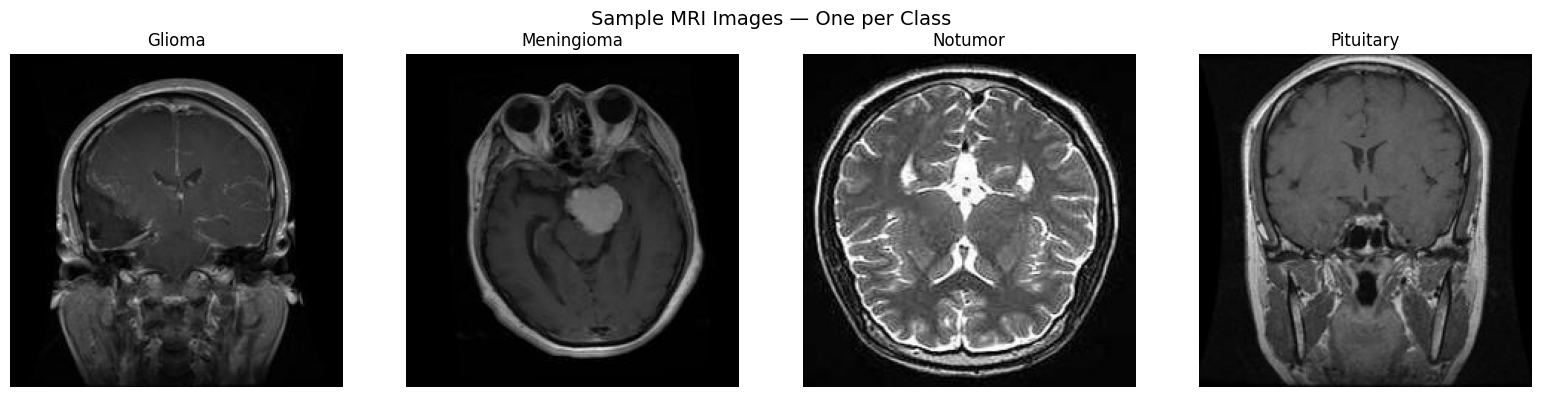

In [ ]:
# ─────────────────────────────────────────────────────────────────────
# Visualize Sample Images
# ─────────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
fig.suptitle("Sample MRI Images — One per Class", fontsize=14)

for idx, class_name in enumerate(class_names):
    class_path = os.path.join("Training", class_name)
    img = None
    for img_name in os.listdir(class_path):
        try:
            img = Image.open(os.path.join(class_path, img_name)).convert("RGB")
            break
        except (OSError, PermissionError):
            continue
    if img:
        axes[idx].imshow(img)
        axes[idx].set_title(class_name.capitalize(), fontsize=12)
        axes[idx].axis("off")

plt.tight_layout()
plt.savefig("sample_images.png", dpi=150)
plt.show()

In [ ]:
# ─────────────────────────────────────────────────────────────────────
# Model — EfficientNetB3 with Transfer Learning
# ─────────────────────────────────────────────────────────────────────

model = models.efficientnet_b3(weights=models.EfficientNet_B3_Weights.DEFAULT)

# Replace classifier head for 4 classes
# EfficientNetB3 feature size: 1536 (vs 1280 for B0)
model.classifier[1] = nn.Linear(
    in_features=model.classifier[1].in_features,
    out_features=len(class_names)
)

model = model.to(device)

# Loss, optimizer, scheduler
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)  # label smoothing reduces overconfidence
optimizer = optim.Adam(model.parameters(), lr=0.0005)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=30)

print(f"Model: EfficientNetB3")
print(f"Output classes: {len(class_names)} — {class_names}")
print(f"Classifier head: {model.classifier[1]}")

Model ready for training
Output classes: 4


In [ ]:
# ─────────────────────────────────────────────────────────────────────
# Training — GPU + Mixed Precision + LR Scheduler
# ─────────────────────────────────────────────────────────────────────

NUM_EPOCHS   = 30
train_losses = []
scaler       = torch.cuda.amp.GradScaler()
best_loss    = float('inf')

for epoch in range(NUM_EPOCHS):
    model.train()
    running_loss = 0.0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()

        with torch.cuda.amp.autocast():
            outputs = model(images)
            loss    = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item()

    epoch_loss = running_loss / len(train_loader)
    train_losses.append(epoch_loss)
    scheduler.step()

    # Save best model
    if epoch_loss < best_loss:
        best_loss = epoch_loss
        torch.save(model.state_dict(), "brain_tumor_model.pth")
        print(f"Epoch [{epoch+1}/{NUM_EPOCHS}]  Loss: {epoch_loss:.4f}  ✓ Best model saved")
    else:
        print(f"Epoch [{epoch+1}/{NUM_EPOCHS}]  Loss: {epoch_loss:.4f}")

print("\nTraining complete. Best model saved as brain_tumor_model.pth")

C:\Users\shrey\AppData\Local\Temp\ipykernel_37000\2950100762.py:7: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler       = torch.cuda.amp.GradScaler()  # AMP scaler for mixed precision
C:\Users\shrey\AppData\Local\Temp\ipykernel_37000\2950100762.py:18: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():          # mixed precision forward pass


Epoch [1/20]  Loss: 0.3050
Epoch [2/20]  Loss: 0.1410
Epoch [3/20]  Loss: 0.0711
Epoch [4/20]  Loss: 0.0666
Epoch [5/20]  Loss: 0.0502
Epoch [6/20]  Loss: 0.0558
Epoch [7/20]  Loss: 0.0424
Epoch [8/20]  Loss: 0.0344
Epoch [9/20]  Loss: 0.0330
Epoch [10/20]  Loss: 0.0230
Epoch [11/20]  Loss: 0.0264
Epoch [12/20]  Loss: 0.0342
Epoch [13/20]  Loss: 0.0325
Epoch [14/20]  Loss: 0.0348
Epoch [15/20]  Loss: 0.0164
Epoch [16/20]  Loss: 0.0208
Epoch [17/20]  Loss: 0.0176
Epoch [18/20]  Loss: 0.0247
Epoch [19/20]  Loss: 0.0292
Epoch [20/20]  Loss: 0.0201

Model saved as brain_tumor_model.pth


Test Accuracy: 93.94%

Per-class metrics:
              precision    recall  f1-score   support

      glioma       1.00      0.77      0.87       400
  meningioma       0.86      0.99      0.92       400
     notumor       0.94      1.00      0.97       400
   pituitary       0.99      1.00      0.99       400

    accuracy                           0.94      1600
   macro avg       0.95      0.94      0.94      1600
weighted avg       0.95      0.94      0.94      1600



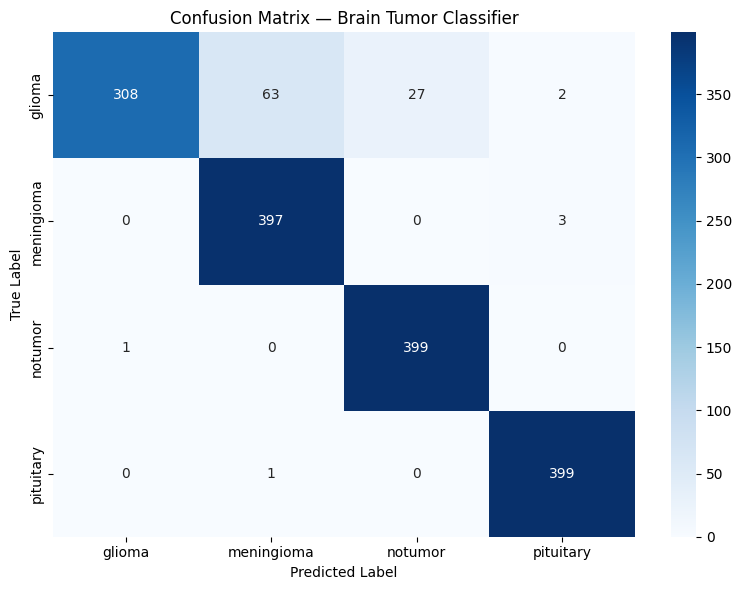

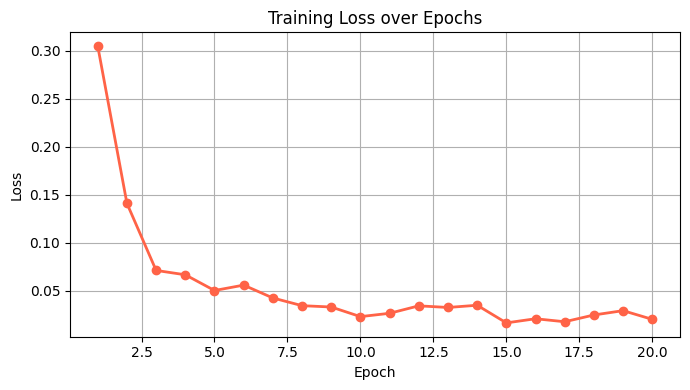

In [ ]:
# ─────────────────────────────────────────────────────────────────────
# Evaluation
# ─────────────────────────────────────────────────────────────────────

# Load best saved model for evaluation
model.load_state_dict(torch.load("brain_tumor_model.pth", weights_only=True))
model.eval()

all_preds  = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs        = model(images)
        _, predicted   = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

accuracy = 100 * (all_preds == all_labels).sum() / len(all_labels)
print(f"Test Accuracy: {accuracy:.2f}%\n")
print("Per-class metrics:")
print(classification_report(all_labels, all_preds, target_names=class_names))

# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title("Confusion Matrix — Brain Tumor Classifier (EfficientNetB3)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()

# Training loss curve
plt.figure(figsize=(8, 4))
plt.plot(range(1, NUM_EPOCHS+1), train_losses,
         marker='o', color='tomato', linewidth=2)
plt.title("Training Loss over Epochs — EfficientNetB3")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.tight_layout()
plt.savefig("training_loss.png", dpi=150)
plt.show()